In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving flights_sample_3m.csv to flights_sample_3m.csv


In [ ]:
df = pd.read_csv("flights_sample_3m.csv")
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Create target variable
df['DELAYED'] = (df['ARR_DELAY'] >= 15).astype(int)

# Drop unnecessary / leakage columns
columns_to_drop = [
    'ARR_DELAY', 'DEP_DELAY', 'DEP_TIME', 'ARR_TIME',
    'WHEELS_OFF', 'WHEELS_ON', 'TAXI_OUT', 'TAXI_IN',
    'AIR_TIME', 'ELAPSED_TIME',
    'AIRLINE_DOT', 'DOT_CODE', 'FL_NUMBER',
    'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT',
    'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED',
    'ORIGIN_CITY', 'DEST_CITY', 'FL_DATE'
]

df = df.drop(columns=columns_to_drop)

# Drop missing values
df = df.dropna()

print("After cleaning:", df.shape)

After cleaning: (2999986, 9)


In [ ]:
# Take a sample to avoid RAM crash
df_sample = df.sample(n=200000, random_state=42)

print("Sample shape:", df_sample.shape)

Sample shape: (200000, 9)


In [ ]:
X = df_sample.drop('DELAYED', axis=1)
y = df_sample['DELAYED']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200000, 8)
y shape: (200000,)


In [ ]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded X shape:", X.shape)
X.head()

Encoded X shape: (200000, 788)


,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,AIRLINE_Allegiant Air,AIRLINE_American Airlines Inc.,AIRLINE_Delta Air Lines Inc.,AIRLINE_Endeavor Air Inc.,AIRLINE_Envoy Air,AIRLINE_ExpressJet Airlines LLC d/b/a aha!,...,DEST_VEL,DEST_VLD,DEST_VPS,DEST_WRG,DEST_WYS,DEST_XNA,DEST_XWA,DEST_YAK,DEST_YKM,DEST_YUM
2920649,2100,2207,67.0,187.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2352586,800,1100,180.0,1127.0,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
908225,705,830,85.0,494.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2825154,1150,1328,158.0,981.0,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2297507,1050,1225,155.0,862.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (160000, 788)
X_test: (40000, 788)


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.822025
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     32881
           1       0.00      0.00      0.00      7119

    accuracy                           0.82     40000
   macro avg       0.41      0.50      0.45     40000
weighted avg       0.68      0.82      0.74     40000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.5428
              precision    recall  f1-score   support

           0       0.87      0.52      0.65     32881
           1       0.23      0.64      0.33      7119

    accuracy                           0.54     40000
   macro avg       0.55      0.58      0.49     40000
weighted avg       0.76      0.54      0.60     40000



In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.819075
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     32881
           1       0.30      0.01      0.02      7119

    accuracy                           0.82     40000
   macro avg       0.56      0.50      0.46     40000
weighted avg       0.73      0.82      0.74     40000



In [ ]:
df['DELAYED'] = df['ARR_DELAY'].apply(lambda x: 1 if x > 0 else 0)

KeyError: 'ARR_DELAY'

In [ ]:
df.columns

Index(['AIRLINE', 'AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME',
       'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'DELAYED'],
      dtype='object')

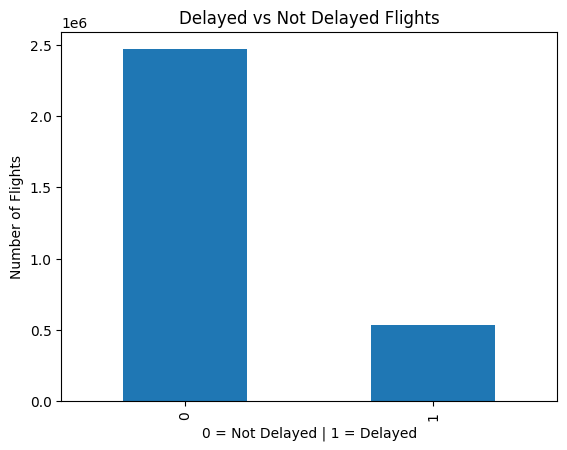

In [ ]:
import matplotlib.pyplot as plt

df['DELAYED'].value_counts().plot(kind='bar')
plt.title("Delayed vs Not Delayed Flights")
plt.xlabel("0 = Not Delayed | 1 = Delayed")
plt.ylabel("Number of Flights")
plt.show()

In [ ]:
delay_causes = [
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]

df[delay_causes].sum().plot(kind='bar')
plt.title("Total Delay Causes")
plt.ylabel("Total Delay Time")
plt.show()

KeyError: "None of [Index(['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',\n       'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT'],\n      dtype='object')] are in the [columns]"

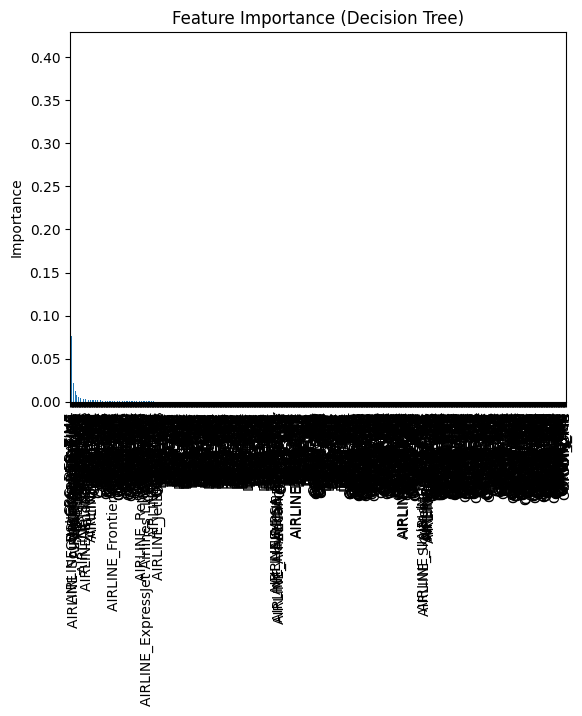

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(tree_model.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar')

plt.title("Feature Importance (Decision Tree)")
plt.ylabel("Importance")
plt.show()

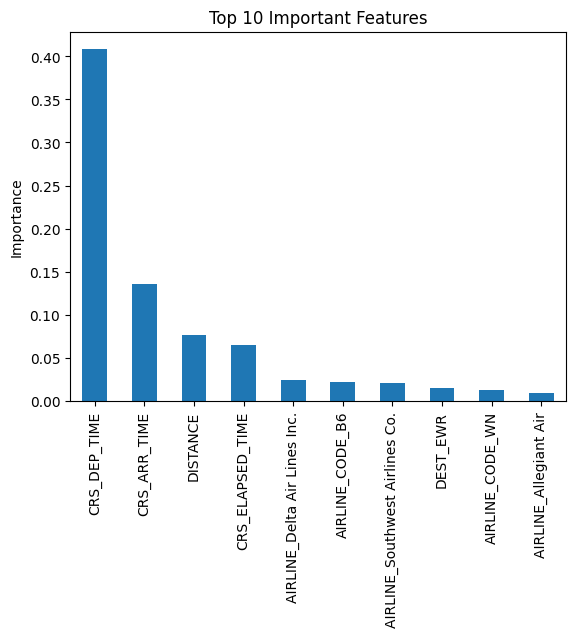

In [ ]:
feature_importance = pd.Series(tree_model.feature_importances_, index=X_train.columns)

top_features = feature_importance.sort_values(ascending=False).head(10)

top_features.plot(kind='bar')

plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()